In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
 #loading dataset
df = pd.read_csv("../Data/TrialFinal.csv")

In [3]:
df.shape

(115, 12)

In [4]:
#null/missing values (show from eda that you identified this -999)
df['irradiance_SW_DWN']= df['irradiance_SW_DWN'].replace(-999, np.nan)   #sentinal value
df.isnull().sum()

year                   0
month                  0
month_num              0
wet_days               6
rainfall               6
male_workforce       105
female_workforce     105
temperature_T2M        0
irradiance_SW_DWN      1
EVI                   30
NDVI                  30
yield                 19
dtype: int64

In [5]:
#handling missing values in labour data
df['male_workforce']= (df.groupby('year')['male_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))
df['female_workforce']= (df.groupby('year')['female_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

#handling correlation between male and female workforce

#creatine a total workforce column
df['total_workforce']=df['female_workforce']+df['male_workforce']

#creating female workforce as a ratio
df['female_workforceRatio']=df['female_workforce']/df['total_workforce']

df.drop(['male_workforce','female_workforce'], axis=1, inplace=True)

# Quick verification
print(df[['total_workforce', 'female_workforceRatio']].head())


   total_workforce  female_workforceRatio
0            901.0               0.560488
1            901.0               0.560488
2            901.0               0.560488
3            901.0               0.560488
4            901.0               0.560488


In [6]:
##new 15.02.2026- adding the code to show seasonality
df["sin_month"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month_num"] / 12)



In [7]:
df = df.dropna(subset=['yield']).reset_index(drop=True)

In [8]:
#adding lags
df = df.sort_values(['year', 'month_num']).reset_index(drop=True)
df['yield_lag_1']=df['yield'].shift(1)
df['yield_lag_2']=df['yield'].shift(2)
df['yield_momentum'] = df['yield_lag_1'] - df['yield_lag_2']
df['yield_lag_3']=df['yield'].shift(3)
df['yield_lag_12'] = df['yield'].shift(12)

df = df.dropna(subset=['yield_lag_1','yield_lag_2','yield_lag_3','yield_lag_12','yield_momentum']).reset_index(drop=True)

#remove rows with missing lags
#df=df.dropna(subset=['yield_lag_1', 'yield_lag_2', 'yield_lag_3']).reset_index(drop=True)

In [9]:
df = df.drop(columns=["month_num"])

In [10]:
df.head(20)

,year,month,wet_days,rainfall,temperature_T2M,irradiance_SW_DWN,EVI,NDVI,yield,total_workforce,female_workforceRatio,sin_month,cos_month,yield_lag_1,yield_lag_2,yield_momentum,yield_lag_3,yield_lag_12
0,2018,April,20.0,373.0,24.06,5.4674,NaN,NaN,72012.0,790.0,0.562025,8.660254e-01,-5.000000e-01,66298.0,57908.0,8390.0,61705.0,75563.0
1,2018,May,26.0,831.0,23.42,4.3080,NaN,NaN,71540.0,790.0,0.562025,5.000000e-01,-8.660254e-01,72012.0,66298.0,5714.0,57908.0,72131.0
2,2018,June,30.0,932.0,22.78,4.6841,NaN,NaN,38362.0,790.0,0.562025,1.224647e-16,-1.000000e+00,71540.0,72012.0,-472.0,66298.0,37098.0
3,2018,July,26.0,809.0,22.38,4.8886,0.239560,0.172064,23203.0,790.0,0.562025,-5.000000e-01,-8.660254e-01,38362.0,71540.0,-33178.0,72012.0,49853.0
4,2018,August,20.0,1055.0,22.18,4.7866,NaN,NaN,26498.0,790.0,0.562025,-8.660254e-01,-5.000000e-01,23203.0,38362.0,-15159.0,71540.0,39997.0
5,2018,September,13.0,275.0,22.83,5.6302,NaN,NaN,39000.0,790.0,0.562025,-1.000000e+00,-1.836970e-16,26498.0,23203.0,3295.0,38362.0,40881.0
6,2018,October,24.0,480.0,22.56,4.5480,NaN,NaN,88699.0,790.0,0.562025,-8.660254e-01,5.000000e-01,39000.0,26498.0,12502.0,23203.0,47635.0
7,2018,November,18.0,231.0,22.28,4.7153,NaN,NaN,46082.0,790.0,0.562025,-5.000000e-01,8.660254e-01,88699.0,39000.0,49699.0,26498.0,48275.0
8,2018,December,9.0,219.0,21.47,4.8010,0.531585,0.689903,53217.0,790.0,0.562025,-2.449294e-16,1.000000e+00,46082.0,88699.0,-42617.0,39000.0,58527.0
9,2019,January,3.0,48.0,21.22,5.4893,0.502249,0.728006,45298.0,746.0,0.569705,5.000000e-01,8.660254e-01,53217.0,46082.0,7135.0,88699.0,61705.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   84 non-null     int64  
 1   month                  84 non-null     object 
 2   wet_days               80 non-null     float64
 3   rainfall               80 non-null     float64
 4   temperature_T2M        84 non-null     float64
 5   irradiance_SW_DWN      84 non-null     float64
 6   EVI                    77 non-null     float64
 7   NDVI                   77 non-null     float64
 8   yield                  84 non-null     float64
 9   total_workforce        84 non-null     float64
 10  female_workforceRatio  84 non-null     float64
 11  sin_month              84 non-null     float64
 12  cos_month              84 non-null     float64
 13  yield_lag_1            84 non-null     float64
 14  yield_lag_2            84 non-null     float64
 15  yield_mo

In [12]:
df.shape

(84, 18)

In [13]:
features = ['rainfall','wet_days','female_workforceRatio','yield_lag_1','yield_lag_2','yield_lag_3','yield_lag_12','irradiance_SW_DWN','sin_month','cos_month','NDVI','EVI','yield_momentum']    #added sin_month and cos_month to features-15.02.2026

target = ['yield']
X=df[features]
Y=df[target]

In [14]:
split_idx=int(len(df)*0.85)
x_train = X.iloc[:split_idx].copy()
y_train = Y.iloc[:split_idx].copy()
x_test = X.iloc[split_idx:].copy()
y_test = Y.iloc[split_idx:].copy()

In [15]:
# Compute month-wise median rainfall from TRAINING set only
rainfall_median_by_month = x_train.groupby(df['month'].iloc[:split_idx])['rainfall'].median()

# Impute training set
x_train['rainfall'] = x_train.apply(
    lambda row: rainfall_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['rainfall']) else row['rainfall'], axis=1
)

# Impute test set using the SAME train-derived medians
x_test['rainfall'] = x_test.apply(
    lambda row: rainfall_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['rainfall']) else row['rainfall'], axis=1
)

In [16]:
# Compute month-wise median wet_days from TRAINING set only
wet_days_median_by_month = x_train.groupby(df['month'].iloc[:split_idx])['wet_days'].median()

# Impute training set
x_train['wet_days'] = x_train.apply(
    lambda row: wet_days_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['wet_days']) else row['wet_days'], axis=1
)

# Impute test set using the SAME train-derived medians
x_test['wet_days'] = x_test.apply(
    lambda row: wet_days_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['wet_days']) else row['wet_days'], axis=1
)

In [17]:
# ── NDVI ──────────────────────────────────────────────────────────────────

# Step 1: Compute IQR bounds from TRAINING set only
Q1_ndvi = x_train['NDVI'].quantile(0.25)
Q3_ndvi = x_train['NDVI'].quantile(0.75)
IQR_ndvi = Q3_ndvi - Q1_ndvi
lower_ndvi = Q1_ndvi - 1.5 * IQR_ndvi
upper_ndvi = Q3_ndvi + 1.5 * IQR_ndvi

# Step 2: Replace outliers with NaN (train and test using TRAIN bounds)
x_train['NDVI'] = x_train['NDVI'].where(
    (x_train['NDVI'] >= lower_ndvi) & (x_train['NDVI'] <= upper_ndvi), np.nan
)
x_test['NDVI'] = x_test['NDVI'].where(
    (x_test['NDVI'] >= lower_ndvi) & (x_test['NDVI'] <= upper_ndvi), np.nan
)

# Step 3: Compute month-wise median from TRAINING set (after outlier removal)
ndvi_median_by_month = x_train.groupby(df['month'].iloc[:split_idx])['NDVI'].median()

# Step 4: Impute training set
x_train['NDVI'] = x_train.apply(
    lambda row: ndvi_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['NDVI']) else row['NDVI'], axis=1
)

# Step 5: Impute test set using SAME train-derived medians
x_test['NDVI'] = x_test.apply(
    lambda row: ndvi_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['NDVI']) else row['NDVI'], axis=1
)


# ── EVI ───────────────────────────────────────────────────────────────────

# Step 1: Compute IQR bounds from TRAINING set only
Q1_evi = x_train['EVI'].quantile(0.25)
Q3_evi = x_train['EVI'].quantile(0.75)
IQR_evi = Q3_evi - Q1_evi
lower_evi = Q1_evi - 1.5 * IQR_evi
upper_evi = Q3_evi + 1.5 * IQR_evi

# Step 2: Replace outliers with NaN (train and test using TRAIN bounds)
x_train['EVI'] = x_train['EVI'].where(
    (x_train['EVI'] >= lower_evi) & (x_train['EVI'] <= upper_evi), np.nan
)
x_test['EVI'] = x_test['EVI'].where(
    (x_test['EVI'] >= lower_evi) & (x_test['EVI'] <= upper_evi), np.nan
)

# Step 3: Compute month-wise median from TRAINING set (after outlier removal)
evi_median_by_month = x_train.groupby(df['month'].iloc[:split_idx])['EVI'].median()

# Step 4: Impute training set
x_train['EVI'] = x_train.apply(
    lambda row: evi_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['EVI']) else row['EVI'], axis=1
)

# Step 5: Impute test set using SAME train-derived medians
x_test['EVI'] = x_test.apply(
    lambda row: evi_median_by_month[df.loc[row.name, 'month']]
    if pd.isna(row['EVI']) else row['EVI'], axis=1
)

In [18]:
# Step 1: Concatenate to create lag correctly across the split boundary
combined = pd.concat([x_train, x_test])
combined['rainfall_lag_1'] = combined['rainfall'].shift(1)

# Step 2: Split back
x_train['rainfall_lag_1'] = combined['rainfall_lag_1'].iloc[:len(x_train)].values
x_test['rainfall_lag_1']  = combined['rainfall_lag_1'].iloc[len(x_train):].values

# Step 3: Impute the NaN in the first row of x_train using train median
rainfall_lag_median = x_train['rainfall_lag_1'].median()
x_train['rainfall_lag_1'] = x_train['rainfall_lag_1'].fillna(rainfall_lag_median)

# Step 4: Add to features list
features = ['rainfall','wet_days','female_workforceRatio',
             'yield_lag_1', 'yield_lag_2', 'yield_lag_3','yield_lag_12','rainfall_lag_1',
             'irradiance_SW_DWN', 'sin_month', 'cos_month','NDVI','EVI','yield_momentum']

In [19]:
x_train = x_train[features]
x_test  = x_test[features]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train only, transform both
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

# Convert back to DataFrame to keep column names
x_train_scaled = pd.DataFrame(x_train_scaled, columns=features, index=x_train.index)
x_test_scaled  = pd.DataFrame(x_test_scaled,  columns=features, index=x_test.index)

In [21]:
#catboost model
cat_model = CatBoostRegressor(iterations = 300,              #from 1000 to 300
                              learning_rate = 0.05,
                              depth = 3,                  #6 to 3
                              loss_function = 'RMSE',
                              eval_metric = 'RMSE',
                              l2_leaf_reg=10,             #new
                              random_seed = 42,
                              verbose = 100)

#fit model
cat_model.fit(x_train_scaled, y_train, eval_set = (x_test_scaled, y_test),early_stopping_rounds = 50)

0:	learn: 13906.8275439	test: 11420.3461426	best: 11420.3461426 (0)	total: 139ms	remaining: 41.7s
100:	learn: 8638.2019381	test: 9483.9643579	best: 9483.9643579 (100)	total: 237ms	remaining: 467ms
200:	learn: 6367.1869199	test: 8408.4119462	best: 8402.6541283 (194)	total: 327ms	remaining: 161ms
299:	learn: 4984.1238618	test: 8004.9555221	best: 8004.9555221 (299)	total: 401ms	remaining: 0us

bestTest = 8004.955522
bestIteration = 299



In [22]:
y_pred_cat = cat_model.predict(x_test_scaled)

In [23]:
mse = mean_squared_error(y_test, y_pred_cat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_cat)
r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Yield Prediction Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")


CatBoost Yield Prediction Performance
RMSE: 8004.96
MAE : 6650.79
R²  : 0.174


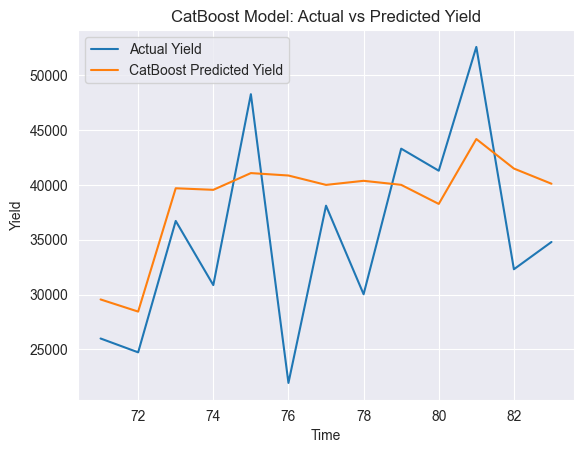

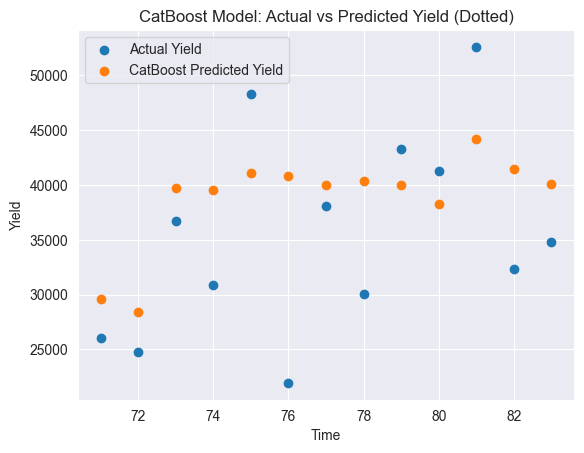

In [24]:
#line plot
plt.figure()

plt.plot(y_test.index, y_test.values, label="Actual Yield")
plt.plot(y_test.index, y_pred_cat, label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

#scatter plot
plt.figure()

plt.scatter(y_test.index, y_test.values,
            label="Actual Yield")

plt.scatter(y_test.index, y_pred_cat,
            label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield (Dotted)")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

In [25]:
#XGBoost on the dataset with ndvi
xgb_model = XGBRegressor(
    n_estimators=200,             #from 300 to 200
    max_depth=3,       #from 4 to 3
    learning_rate=0.05,
    subsample=0.7,                 #from 0.8
    colsample_bytree=0.7,           #from 0.8
    objective="reg:squarederror",
    random_state=42
)

# xgb_model = XGBRegressor(
#     n_estimators=500,        # more trees
#     max_depth=5,             # deeper trees
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,           # less regularisation
#     reg_lambda=1.0,          # less regularisation
#     random_state=42
# )



xgb_model.fit(x_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [26]:
# --- 2. PREDICT & UN-SCALE ---
# The model outputs scaled predictions (small decimals)
y_pred_xgb = xgb_model.predict(x_test_scaled)

#

In [27]:
#y_pred_xgb = xgb_model.predict(x_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae  = mean_absolute_error(y_test, y_pred_xgb)
r2   = r2_score(y_test, y_pred_xgb)

print("Model A — XGBoost Yield Prediction")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")

Model A — XGBoost Yield Prediction
RMSE: 6143.22
MAE : 5151.27
R²  : 0.514


In [28]:
# ← add this right here
mape = np.mean(np.abs((y_test.values - y_pred_xgb) / y_test.values)) * 100
print(f"MAPE: {mape:.1f}%")

MAPE: 25.8%


In [29]:
# # ← add this right after
# y_pred_train = xgb_model.predict(x_train)
# r2_train = r2_score(y_train, y_pred_train)
# print(f"\n--- Overfitting Check ---")
# print(f"Train R²: {r2_train:.3f}")
# print(f"Test  R²: {r2:.3f}")
# print(f"Gap     : {r2_train - r2:.3f}")

#newwwwwwww you can remove 14.03.2026 cz it do the same as above
y_pred_train = xgb_model.predict(x_train)
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_xgb)    # ← compute test R² fresh here

print(f"\n--- Overfitting Check ---")
print(f"Train R²: {r2_train:.3f}")
print(f"Test  R²: {r2_test:.3f}")
print(f"Gap     : {r2_train - r2_test:.3f}")


--- Overfitting Check ---
Train R²: 0.114
Test  R²: 0.514
Gap     : -0.399


In [30]:
#newwwwwwww you can remove 14.03.2026
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)
print('y_train shape:', y_train.shape)
print()
print('Sample predictions on train:')
print('Predicted:', xgb_model.predict(x_train)[:5])
print('Actual:   ', y_train.values[:5].ravel())

x_train shape: (71, 14)
x_test shape: (13, 14)
y_train shape: (71, 1)

Sample predictions on train:
Predicted: [46729.605 45970.105 41587.594 38267.633 38833.355]
Actual:    [72012. 71540. 38362. 23203. 26498.]


In [31]:
# check train R² without those first 2 rows
from sklearn.metrics import r2_score
r2_without_outliers = r2_score(
    y_train.iloc[2:],
    xgb_model.predict(x_train.iloc[2:])
)
print(f'Train R² without first 2 rows: {r2_without_outliers:.3f}')

Train R² without first 2 rows: 0.095


In [32]:
#newwwwwwww you can remove 14.03.2026
print(y_train.head(5))
print(x_train.head(5))

     yield
0  72012.0
1  71540.0
2  38362.0
3  23203.0
4  26498.0
   rainfall  wet_days  female_workforceRatio  yield_lag_1  yield_lag_2  \
0     373.0      20.0               0.562025      66298.0      57908.0   
1     831.0      26.0               0.562025      72012.0      66298.0   
2     932.0      30.0               0.562025      71540.0      72012.0   
3     809.0      26.0               0.562025      38362.0      71540.0   
4    1055.0      20.0               0.562025      23203.0      38362.0   

   yield_lag_3  yield_lag_12  rainfall_lag_1  irradiance_SW_DWN     sin_month  \
0      61705.0       75563.0           403.0             5.4674  8.660254e-01   
1      57908.0       72131.0           373.0             4.3080  5.000000e-01   
2      66298.0       37098.0           831.0             4.6841  1.224647e-16   
3      72012.0       49853.0           932.0             4.8886 -5.000000e-01   
4      71540.0       39997.0           809.0             4.7866 -8.660254e-01   

  

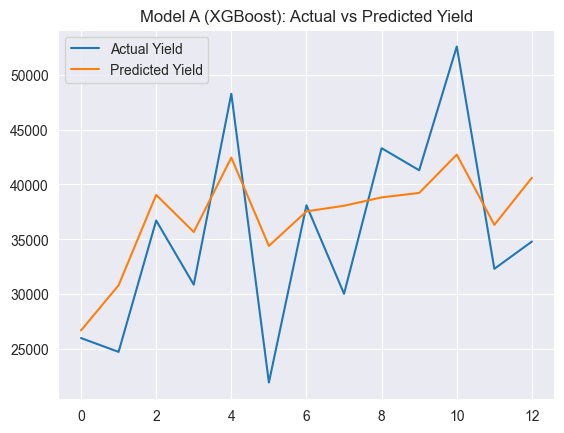

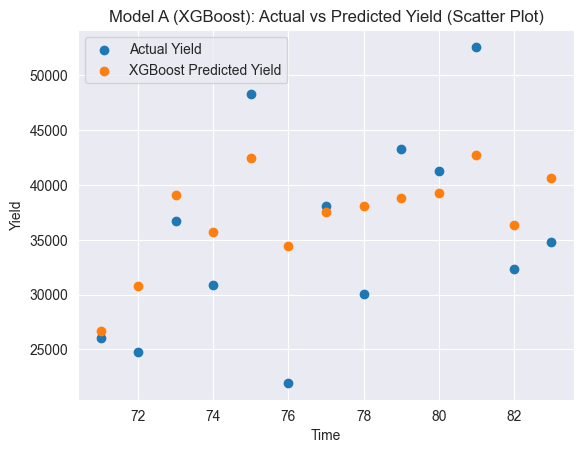

In [33]:
plt.figure()
plt.plot(y_test.values, label="Actual Yield")
plt.plot(y_pred_xgb, label="Predicted Yield")
plt.legend()
plt.title("Model A (XGBoost): Actual vs Predicted Yield")
plt.show()

plt.figure()

#scatter plot
plt.scatter(y_test.index, y_test.values, label="Actual Yield")
plt.scatter(y_test.index, y_pred_xgb, label="XGBoost Predicted Yield")
plt.legend()
plt.title("Model A (XGBoost): Actual vs Predicted Yield (Scatter Plot)")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()



In [34]:
#trying a basic ensemble method with xgboost and catboost
y_pred_avg = (y_pred_xgb+y_pred_cat)/2

mse = mean_squared_error(y_test, y_pred_avg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_avg)
r2 = r2_score(y_test, y_pred_avg)

print("Ensemble (XGBoost + CatBoost) Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")

Ensemble (XGBoost + CatBoost) Performance
RMSE: 6977.50
MAE : 5858.22
R²  : 0.373


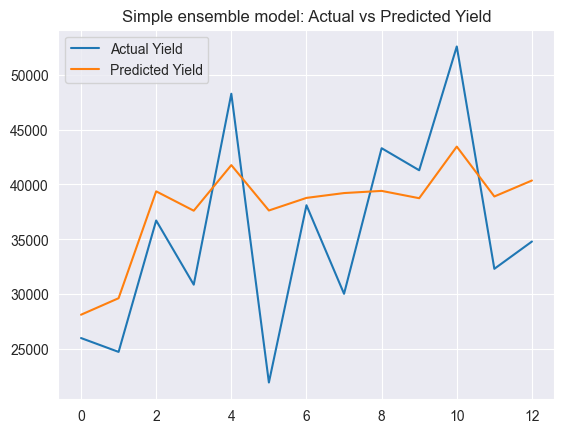

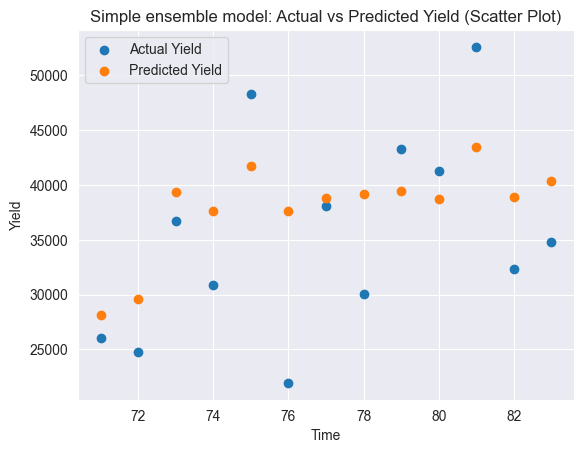

In [35]:
plt.figure()
plt.plot(y_test.values, label="Actual Yield")
plt.plot(y_pred_avg, label="Predicted Yield")
plt.legend()
plt.title("Simple ensemble model: Actual vs Predicted Yield")
plt.show()

plt.figure()

#scatter plot
plt.scatter(y_test.index, y_test.values, label="Actual Yield")
plt.scatter(y_test.index, y_pred_avg, label="Predicted Yield")
plt.legend()
plt.title("Simple ensemble model: Actual vs Predicted Yield (Scatter Plot)")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gbm = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=2,          # very shallow — fights overfitting
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gbm.fit(x_train, y_train)
y_pred_gbm = gbm.predict(x_test)
print(f'GBM R²: {r2_score(y_test, y_pred_gbm):.3f}')

GBM R²: 0.307


C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
